In [ ]:
# Without this, you’d have to manually download + parse dataset.
import torchvision
#Transforms = operations applied to data before using it
# convert raw images → usable tensors
import torchvision.transforms as transforms
# Used for visualization
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------
# Step 1: Load + Normalize
# -----------------------------
# Converts image to tensor → tensor and Normalizes values
transform = transforms.ToTensor()

# You are creating a dataset object
# Folder where dataset will be stored
# If not present → created automatically
# Your data lives here locally

# True → load training data (60,000 samples)
# False → loads test data (10,000)

# If dataset not present → download it
# If already present → skip download

# This applies: ToTensor() to every image automatically
# So each sample becomes:
# (image_tensor, label) 
# instead of: (raw_image, label)

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [ ]:
# -----------------------------
# Step 2: Split dataset into training and validation sets
# -----------------------------

# Calculate 80% of total dataset for training
train_size = int(0.8 * len(dataset))

# Remaining 20% for validation
val_size = len(dataset) - train_size

# Randomly split dataset into train and validation subsets
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size]
)

# Print sizes to verify correct split
print("Total dataset size :",len(dataset)) # Expected 60,000
print("Train size:", len(train_dataset))        # Expected: 48,000
print("Validation size:", len(val_dataset))     # Expected: 12,000

Total dataset size : 60000
Train size: 48000
Validation size: 12000


In [ ]:
# -----------------------------
# Step 3: Flatten image (28x28 → 784)
# -----------------------------

# Get one sample from training dataset
# image → tensor of shape [1, 28, 28]
# label → class label (0–9)
# What does [1, 28, 28] mean ?
# 1 → number of channels (grayscale image)
# 28 × 28 → height × width
# So it’s a 2D image with one channel

image, label = train_dataset[0]
print("Image : ",image)
print("Label : ",label)

# Flatten image into 1D vector
# view(-1) reshapes tensor while keeping total elements same
# [1, 28, 28] → [784]
# .view() reshapes a tensor
# -1 means:
# “figure out the size automatically”

flat_image = image.view(-1)

# Print shapes to verify transformation
print("Original shape:", image.shape)       # [1, 28, 28]
print("Flattened shape:", flat_image.shape) # [784]

Image :  tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0039, 0.0000, 0.0000, 0.0157, 0.4000, 0.5020, 0.5765, 0.4784,
          0.1373, 0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.4627, 0.8941, 0.9373, 0.9373, 0.9255, 0.9451,
          0.9608, 0.7647, 0.0549, 0.0000, 0.0118, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118,
          0.0000, 0.0000, 0.7412, 0.9333, 0.8902, 0.8745, 0.8824, 0.9176,
          0.9255, 0.9373, 0.2353, 0.0000, 0.0157, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.1294, 0.8980, 0.8235, 0.6667, 0.7882, 0.8275, 0.6549,
          0.6824, 0.8510, 0.3490, 0.0000, 0.0000

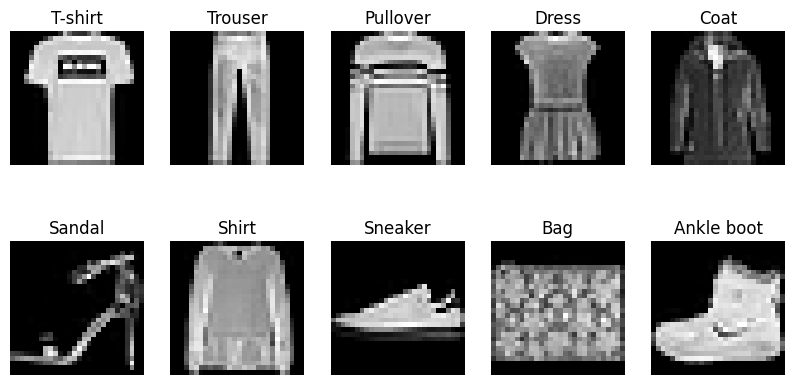

In [ ]:
# -----------------------------
# Step 4: Visualization
# -----------------------------

# Class names corresponding to labels (0–9)
classes = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Create a 2x5 grid of plots
fig, axes = plt.subplots(2, 5, figsize=(10,5))

# Set to track which classes are already displayed
shown = set()

# Loop through dataset
for img, label in dataset:

    # Show only one image per class
    if label not in shown:

        # Map label to grid position
        ax = axes[label // 5][label % 5]

        # Display image (remove channel dimension)
        ax.imshow(img.squeeze(), cmap='gray')

        # Set class name as title
        ax.set_title(classes[label])

        # Remove axis for clean view
        ax.axis('off')

        # Mark this class as shown
        shown.add(label)

    # Stop when all 10 classes are displayed
    if len(shown) == 10:
        break

# Display the plot
plt.show()